# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2
from sklearn.preprocessing import OneHotEncoder

# evaluation
import datetime
from tqdm.auto import tqdm as _tqdm

# model visualization
from torchinfo import summary

# reset working dir
import os
from pathlib import Path


In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_24h.parquet")

In [4]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28100,2025-12-31,490872,73,residential,11,10,53.181818,1322.818182,10.206364,27.328182,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
28101,2025-12-31,490872,74,residential,6,5,63.000000,1984.333333,11.760000,33.335000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
28102,2025-12-31,490872,75,residential,14,13,39.545455,1283.214286,11.902857,30.803571,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
28103,2025-12-31,490872,76,airport,1553,824,127.081784,2054.041211,14.628880,38.528210,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     28,105
Unique combinations (no time) :     28,105
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   28,105 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :       77
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :      318  (1.1%)
Non-zero-demand rows           :   27,787  (98.9%)


In [6]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "adam"
LEARNING_RATE      = 5e-5
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "mse"  # "mse" | "mae" | "poisson_nll" (Poisson NLL on raw counts, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}


HP_SEARCH_SEEDS        = (0,)
HP_PATIENCE            = 10
BEST_HP                = {}


## 4.2.3 Model Definition

In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") != "poisson_nll":
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(λ), consumed by PoissonNLLLoss(log_input=True)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None):
    set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    else:
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # "poisson_nll": model outputs log-rate; exp() applied internally

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=_lr)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = _tqdm(train_dl, leave=True, unit="step", disable=not verbose)
        for xb, yb in pbar:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix({"loss": f"{running_loss / n_batches:.4f}"})
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        pbar.set_postfix({"loss": f"{train_loss:.4f}", "val_loss": f"{val_loss:.4f}"})
        pbar.close()
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    model.load_state_dict(best_state)
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  device='cpu',
                  lr_candidates=None, seeds=None):
    import itertools

    lr_candidates = lr_candidates or HP_LR_CANDIDATES
    seeds         = seeds         or HP_SEARCH_SEEDS
    arch_label    = ARCH_NAMES.get(arch, str(arch))

    combos = list(itertools.product(lr_candidates))

    print(f'HP Search — {arch_label}')
    print(f'{len(combos)} combos × {len(seeds)} seed(s)'
          f' = {len(combos) * len(seeds)} runs  |  patience={HP_PATIENCE}\n')
    print(f"{{'#':>4}}  {{'lr':>8}}  {{'mean val':>10}}  {{'std':>8}}")
    print('-' * 35)

    results = []
    for i, (lr,) in enumerate(combos, 1):
        val_losses = []
        for seed in seeds:
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                seed=seed, device=device, verbose=False,
                lr=lr, patience=HP_PATIENCE,
            )
            val_losses.append(val_loss)
        mean_loss = float(np.mean(val_losses))
        std_loss  = float(np.std(val_losses))
        results.append({
            'lr': lr,
            'mean_val_loss': mean_loss, 'std_val_loss': std_loss,
        })
        print(f'{i:>4}  {lr:>8.0e}  {mean_loss:>10.4f}  {std_loss:>8.4f}')

    results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
    print(f'\n--- Top 5 ---')
    print(results_df.head(5).to_string(index=False))

    best = results_df.iloc[0]
    BEST_HP[arch] = {'lr': float(best['lr'])}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌──────────────────────┬──────────────────────────────┬─────────────┐
│ pickup_community_area│  is_weekend, temp, rain, ...  │ trip_count  │
│         8            │  0,  12.3,  0.0,  ...        │      5      │
└──────────┬───────────┴───────────────┬───────────────┴──────┬──────┘
           │                           │                       │
           ▼                           ▼                       ▼
     OneHotEncoder               StandardScaler            target y
  area_8=1, rest=0           [0.0, -0.3, ...]               5.0
  (n_ca binary columns)       (n_num scaled columns)
           │                           │
           └──────────────┬────────────┘
                          ▼
                    np.concatenate
         [0, ..., 1, ..., 0,  0.0, -0.3, ...]
               (n_ca + n_num total dims)
                          │
                          ▼
              ┌─────────────────────┐
              │  Linear(dim → 64)   │
              │  ReLU               │
              │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
              │  ReLU               │
              │  Linear(64 → 1)     │
              │  Softplus           │  ← keeps output ≥ 0 (trip count)
              └─────────────────────┘
                          │
                          ▼
                   ŷ  (predicted trip count)
```

Community area identity is encoded as a one-hot vector (fit on training data only).
The network learns a separate weight for each area directly in the first linear layer.

## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [10]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    19,673 rows
Val   :     4,216 rows
Test  :     4,216 rows


In [11]:
train_data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Community Area Encoding

Community area identity is encoded using **one-hot encoding** (fit on the training
set only). Each of the `n_ca` unique areas becomes a binary indicator column,
concatenated with the scaled numeric features before the first linear layer.

This replaces the learnable embedding used in the hexagon notebooks. With only
~77 areas the one-hot representation is compact enough to be practical, and it
has the advantage of being directly interpretable — each area gets its own
explicit weight vector in the first layer.

In [12]:
LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    # 'temperature_2m', 
    'apparent_temperature',
    # 'precipitation',
    # 'rain', 'snowfall',
    # 'wind_speed_10m',
    'cloud_cover', 'is_day', 
    # 'area_km2',
    # 'dist_to_nearest_airport_km',
    'dist_to_nearest_train_station_km',
    # 'dist_to_nearest_stadium_km',
    'train_station_per_km2',
    # 'restaurants_per_km2',
    # 'bars_and_clubs_per_km2',
    # 'hotels_per_km2',
    'hospitals_per_km2',
    'universities_per_km2',
    'attractions_per_km2', 'poi_density_total_per_km2'
    ]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Numeric features (20): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2']


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. univariate feature testing
3. model-based feature importance

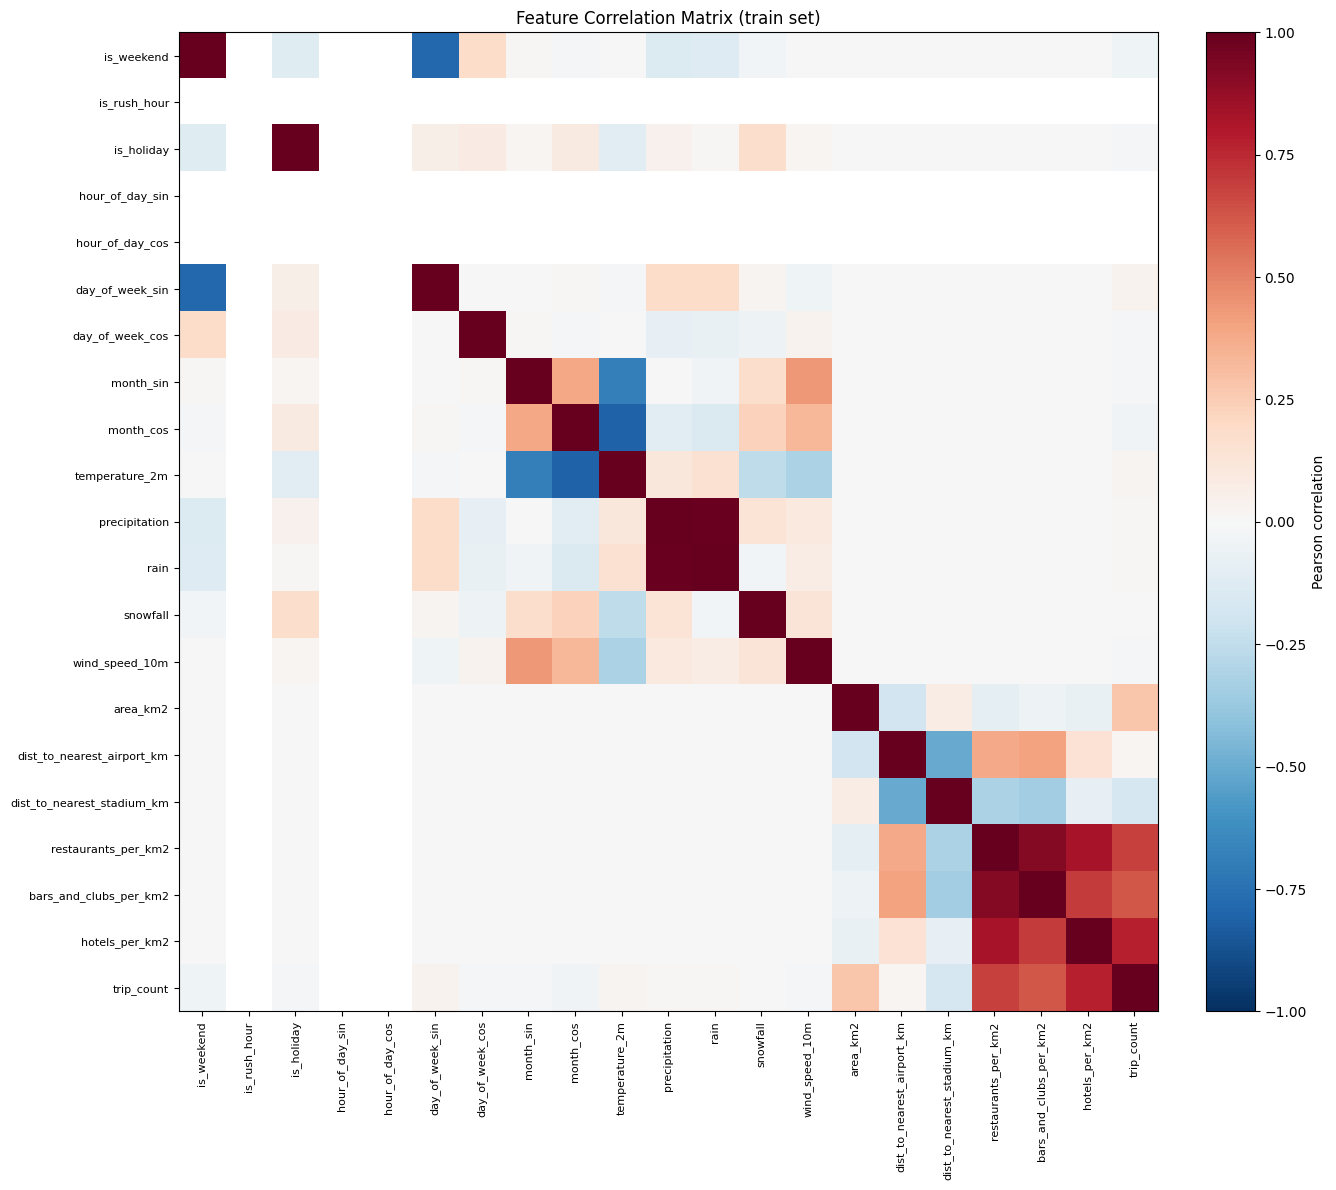

Feature pairs with |correlation| >= 0.8:
  precipitation                       vs rain                                 r=+0.986
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820
  month_cos                           vs temperature_2m                       r=-0.805


In [13]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")


In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Univariate Tests                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.feature_selection import f_regression, mutual_info_regression

X_uni = train_data[FEATURE_COLS].values
y_uni = train_data[TARGET_COL].values

f_scores, f_pvalues = f_regression(X_uni, y_uni)
mi_scores           = mutual_info_regression(X_uni, y_uni, random_state=0)

univariate_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "f_score":     f_scores,
    "f_pvalue":    f_pvalues,
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=False).reset_index(drop=True)

print(univariate_df.to_string(index=False))

# Features with no significant univariate linear relationship (F-test)
ALPHA = 0.05
insignificant = univariate_df.loc[univariate_df["f_pvalue"] > ALPHA, "feature"].tolist()
print(f"\nFeatures with F-test p-value > {ALPHA} (no significant linear relationship with target):")
print(f"  {insignificant if insignificant else 'none'}")


                   feature      f_score      f_pvalue  mutual_info
dist_to_nearest_airport_km     8.682276  3.216962e-03     1.620155
                  area_km2  1622.564227  0.000000e+00     1.603694
dist_to_nearest_stadium_km   596.578248 7.945480e-130     1.589795
       restaurants_per_km2 17242.540125  0.000000e+00     1.471721
    bars_and_clubs_per_km2 12370.624189  0.000000e+00     1.428887
            hotels_per_km2 29971.315273  0.000000e+00     0.651751
                is_weekend    33.420001  7.537988e-09     0.011772
           day_of_week_sin    27.153504  1.898209e-07     0.011091
                  snowfall     0.906383  3.410877e-01     0.008180
           day_of_week_cos     5.728950  1.669677e-02     0.006668
                is_holiday     3.444536  6.347617e-02     0.004216
           hour_of_day_sin     0.000000  1.000000e+00     0.000987
                 month_cos    27.339689  1.724176e-07     0.000386
                 month_sin     2.575678  1.085337e-01     0.00

In [15]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")


                   feature  rf_importance  perm_importance  perm_importance_std
            hotels_per_km2       0.620257         1.295373             0.014737
dist_to_nearest_airport_km       0.131169         0.150784             0.001622
                  area_km2       0.112511         0.095147             0.001052
dist_to_nearest_stadium_km       0.033822         0.042845             0.000582
           day_of_week_sin       0.023779         0.040109             0.001331
                 month_cos       0.012016         0.021055             0.000643
            temperature_2m       0.013166         0.015528             0.000480
                is_weekend       0.011174         0.011674             0.000598
           day_of_week_cos       0.005033         0.009443             0.000654
    bars_and_clubs_per_km2       0.015607         0.008282             0.000158
            wind_speed_10m       0.005235         0.006450             0.000273
                 month_sin       0.00268

In [16]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# One-hot encode community area (fit on train only to avoid leakage)
ohe          = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ca_train_ohe = ohe.fit_transform(train_data[['pickup_community_area']])
ca_val_ohe   = ohe.transform(val_data[['pickup_community_area']])
ca_test_ohe  = ohe.transform(test_data[['pickup_community_area']])

scaler      = StandardScaler()
X_train_num = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val_num   = scaler.transform(val_data[FEATURE_COLS].values)
X_test_num  = scaler.transform(test_data[FEATURE_COLS].values)

X_train = np.concatenate([X_train_num, ca_train_ohe], axis=1)
X_val   = np.concatenate([X_val_num,   ca_val_ohe],   axis=1)
X_test  = np.concatenate([X_test_num,  ca_test_ohe],  axis=1)

IS_POISSON = (getattr(config, "LOSS", "mse") == "poisson_nll")

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (Poisson NLL)' if IS_POISSON else 'log1p'}")

n_ca = ca_train_ohe.shape[1]
print(f"Community area one-hot columns : {n_ca}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Target scale : log1p
Community area one-hot columns : 77

X_train : (19673, 97)   y_train : (19673,)
X_val   : (4216, 97)     y_val   : (4216,)
X_test  : (4216, 97)    y_test  : (4216,)


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157

Historical mean (area × hour)        R²=0.8676  MAE=60.8814  RMSE=227.1378  NRMSE=1.2653
Ridge regression                     R²=0.8561  MAE=56.9275  RMSE=236.8031  NRMSE=1.3191


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [18]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width)
x_dummy   = torch.zeros(1, input_dim)
summary(viz_model, input_data=x_dummy, col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 97]                   [1]                       --
├─Sequential: 1-1                        [1, 97]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 97]                   [1, 64]                   6,272
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 10,497
Trainable params: 10,497
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 97]                   [1]                       --
├─Sequential: 1-1                        [1, 97]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 97]                   [1, 64]                   6,272
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 10,497
Trainable params: 10,497
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

In [19]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 10.3866  val_loss: 9.7688 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 10.0486  val_loss: 9.5252 ✓
Epoch   3/200


...

  loss: 0.1139  val_loss: 0.2370 ✓
Epoch 199/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.1129  val_loss: 0.2363 ✓
Epoch 200/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.1132  val_loss: 0.2355 ✓

baseline  train: 0.1132 ± 0.0000  val: 0.2355 ± 0.0000


### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [20]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, baseline_models):
    model.eval()

    print(f"  seed={seed} layer weight stats:")
    for name, param in model.named_parameters():
        if "weight" in name:
            w = param.detach().cpu().numpy()
            print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                  f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : baseline_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} \u00b1 {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} \u00b1 {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, baseline_train_losses, baseline_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(baseline_train_losses):>8.4f}  {np.mean(baseline_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0 layer weight stats:
    net.0.weight    shape=(64, 97)      max|w|=0.7162  mean|w|=0.1257  norm=12.4640
    net.2.weight    shape=(64, 64)      max|w|=0.6334  mean|w|=0.1440  norm=11.5273
    net.4.weight    shape=(1, 64)       max|w|=0.4155  mean|w|=0.1535  norm=1.4998
  seed=0  R²=-4.3462  MAE=132.4840  NRMSE=8.0396  | log  R²=0.8011  MAE=0.5045  NRMSE=0.2361  | zeros 0/67  false=0  | pred min=1.0 max=62403.7

--- original scale ---
Baseline  R²    : -4.3462 ± 0.0000
Baseline  MAE   : 132.4840 ± 0.0000
Baseline  RMSE  : 1443.2418 ± 0.0000
Baseline  NRMSE : 8.0396 ± 0.0000

--- log1p scale ---
Baseline  R²    : 0.8011 ± 0.0000
Baseline  MAE   : 0.5045 ± 0.0000
Baseline  RMSE  : 0.7508 ± 0.0000
Baseline  NRMSE : 0.2361 ± 0.0000

--- zero-demand ---
Baseline  Correct-zero : 0.0 ± 0.0  (out of 67)
Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction r

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [21]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_24h.csv (23 columns)
          timestamp loss    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2        mae        rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max
2026-07-09T14:04:44  mse baseline         2     64        0.00005        1024     0  0.235532                 67   179.515655 -4.346229 132.484042 1443.241839 8.039643 0.801076 0.504465   0.75085   0.236084             0           0  0.954216 62403.714844


## 4.2.10 Hyperparameter Search — Baseline Model

Grid search over 4 hyperparameters using the best LR from the LR search above.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_BASELINE]`.


In [22]:
# HP search candidates — Baseline (2 layers × 64 units)
# Narrow range first; widen if best LR sits at an edge
# LR_CANDIDATES_BASELINE = [2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4, 2e-4, 3e-4, 5e-4]
# LR_CANDIDATES_BASELINE = [6e-5, 7e-5, 1e-4, 2e-4, 3e-4, 5e-4]
# LR_CANDIDATES_BASELINE = [7e-5, 8e-5, 9e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3, 2e-3, 5e-3]
LR_CANDIDATES_BASELINE = [7e-3, 8e-3, 9e-3, 1e-2, 2e-2, 5e-2, 6e-2, 7e-2]

In [23]:
run_hp_search(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_BASELINE,
)

HP Search — baseline
8 combos × 1 seed(s) = 8 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     7e-03      0.2060    0.0000
   2     8e-03      0.2013    0.0000
   3     9e-03      0.2048    0.0000
   4     1e-02      0.2006    0.0000
   5     2e-02      0.1912    0.0000
   6     5e-02      0.1778    0.0000
   7     6e-02      0.1795    0.0000
   8     7e-02      0.1828    0.0000

--- Top 5 ---
  lr  mean_val_loss  std_val_loss
0.05       0.177768           0.0
0.06       0.179501           0.0
0.07       0.182834           0.0
0.02       0.191163           0.0
0.01       0.200617           0.0

BEST_HP[baseline] = {'lr': 0.05}


{'lr': 0.05}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [24]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.05}

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 2.2299  val_loss: 0.2836 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.2008  val_loss: 0.1842 ✓
Epoch   3/200


...

  loss: 0.0732  val_loss: 0.1905  (no improvement 8/10)
Epoch  12/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0724  val_loss: 0.1975  (no improvement 9/10)
Epoch  13/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0722  val_loss: 0.1930  (no improvement 10/10)

  ↳ early stop at epoch 13  best_val=0.1778  best_train=0.1030

baseline  train: 0.1030 ± 0.0000  val: 0.1778 ± 0.0000


### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [25]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_models):
    model.eval()
    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : "baseline_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_BASELINE]["lr"],
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : tuned_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : mean_actual,
        "r2"                : r2,
        "mae"               : mae,
        "rmse"              : rmse,
        "nrmse"             : nrmse,
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Baseline  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Baseline  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} \u00b1 {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} \u00b1 {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_train_losses, tuned_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_train_losses):>8.4f}  {np.mean(tuned_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.6967  MAE=79.6003  NRMSE=1.9149  | log  R²=0.9074  MAE=0.3887  NRMSE=0.1610  | zeros 0/67  false=0  | pred min=1.4 max=6282.2

--- original scale ---
Tuned Baseline  R²    : 0.6967 ± 0.0000
Tuned Baseline  MAE   : 79.6003 ± 0.0000
Tuned Baseline  RMSE  : 343.7528 ± 0.0000
Tuned Baseline  NRMSE : 1.9149 ± 0.0000

--- log1p scale ---
Tuned Baseline  R²    : 0.9074 ± 0.0000
Tuned Baseline  MAE   : 0.3887 ± 0.0000
Tuned Baseline  RMSE  : 0.5122 ± 0.0000
Tuned Baseline  NRMSE : 0.1610 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 1.4303 ± 0.0000
Baseline  Pred max : 6282.1963 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0

In [26]:
results_df

,timestamp,loss,model,n_layers,width,learning_rate,batch_size,seed,val_loss,zero_demand_count,...,rmse,nrmse,r2_log,mae_log,rmse_log,nrmse_log,correct_zero,false_zero,pred_min,pred_max
0,2026-07-09T14:04:44,mse,baseline,2,64,0.00005,1024,0,0.235532,67,...,1443.241839,8.039643,0.801076,0.504465,0.75085,0.236084,0,0,0.954216,62403.714844


In [27]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_24h.csv (23 columns)
          timestamp loss          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae       rmse   nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max
2026-07-09T14:04:53  mse baseline_tuned         2     64           0.05        1024     0  0.177768                 67   179.515655 0.696707 79.60035 343.752799 1.91489 0.907449 0.388663  0.512153   0.161033             0           0  1.430295 6282.196289


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [28]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 9.3453  val_loss: 8.8035 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 8.4790  val_loss: 8.0225 ✓
Epoch   3/200


...

  loss: 0.0907  val_loss: 0.3025  (no improvement 5/10)
Epoch 199/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0896  val_loss: 0.3036  (no improvement 6/10)
Epoch 200/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0903  val_loss: 0.3016 ✓

deep  train: 0.0903 ± 0.0000  val: 0.3016 ± 0.0000


### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [29]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, deeper_models):
    model.eval()
    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} \u00b1 {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} \u00b1 {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, deeper_train_losses, deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(deeper_train_losses):>8.4f}  {np.mean(deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=-459.4030  MAE=561.0093  NRMSE=74.6074  | log  R²=0.7238  MAE=0.5715  NRMSE=0.2782  | zeros 0/67  false=0  | pred min=1.0 max=598613.4

--- original scale ---
Deep  R²    : -459.4030 ± 0.0000
Deep  MAE   : 561.0093 ± 0.0000
Deep  RMSE  : 13393.2018 ± 0.0000
Deep  NRMSE : 74.6074 ± 0.0000

--- log1p scale ---
Deep  R²    : 0.7238 ± 0.0000
Deep  MAE   : 0.5715 ± 0.0000
Deep  RMSE  : 0.8848 ± 0.0000
Deep  NRMSE : 0.2782 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 0.0 ± 0.0  (out of 67)
Deep  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.9906 ± 0.0000
Deep  Pred max : 598613.3750 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.0903    0.3016    0.7828


In [30]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_24h.csv (23 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual          r2        mae         rmse     nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max
2026-07-09T14:05:09  mse  deep         8     64        0.00005        1024     0  0.301626                 67   179.515655 -459.403045 561.009344 13393.201837 74.607431 0.72379 0.571474  0.884766   0.278191             0           0  0.990558 598613.375


## 4.2.12 Hyperparameter Search — Deeper Model

Same grid search as for the baseline, run on `ARCH_DEEPER = (4 hidden layers, 64 units)`.
Result is stored in `BEST_HP[ARCH_DEEPER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_DEEPER]`.

In [31]:
# HP search candidates — Deeper (4 layers × 64 units)
# Deeper networks often need a smaller LR to stay stable
# LR_CANDIDATES_DEEPER   = [7e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3]
LR_CANDIDATES_DEEPER = [2e-4, 3e-4, 5e-4, 7e-4, 8e-4, 9e-4, 1e-3, 2e-3, 5e-3, 6e-3, 7e-3]

In [32]:
run_hp_search(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_DEEPER,
)

HP Search — deep
11 combos × 1 seed(s) = 11 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     2e-04      0.2629    0.0000
   2     3e-04      0.2487    0.0000
   3     5e-04      0.2270    0.0000
   4     7e-04      0.2338    0.0000
   5     8e-04      0.2197    0.0000
   6     9e-04      0.2209    0.0000
   7     1e-03      0.2166    0.0000
   8     2e-03      0.2137    0.0000
   9     5e-03      0.1986    0.0000
  10     6e-03      0.1982    0.0000
  11     7e-03      0.1895    0.0000

--- Top 5 ---
   lr  mean_val_loss  std_val_loss
0.007       0.189479           0.0
0.006       0.198236           0.0
0.005       0.198601           0.0
0.002       0.213718           0.0
0.001       0.216552           0.0

BEST_HP[deep] = {'lr': 0.007}


{'lr': 0.007}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [33]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} \u00b1 {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} \u00b1 {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.007}

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 4.8574  val_loss: 1.2122 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.7390  val_loss: 0.5916 ✓
Epoch   3/200


...

  loss: 0.0661  val_loss: 0.1922  (no improvement 8/10)
Epoch  20/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0663  val_loss: 0.2019  (no improvement 9/10)
Epoch  21/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0651  val_loss: 0.2089  (no improvement 10/10)

  ↳ early stop at epoch 21  best_val=0.1895  best_train=0.0754

deep  train: 0.0754 ± 0.0000  val: 0.1895 ± 0.0000


### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [34]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_deeper_models):
    model.eval()
    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : "deep_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_DEEPER]["lr"],
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : tuned_deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Deeper  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Deeper  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Deeper  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Deeper  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} \u00b1 {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} \u00b1 {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_deeper_train_losses, tuned_deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_deeper_train_losses):>8.4f}  {np.mean(tuned_deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.7103  MAE=77.6901  NRMSE=1.8714  | log  R²=0.8641  MAE=0.4370  NRMSE=0.1951  | zeros 0/67  false=0  | pred min=1.0 max=9360.3

--- original scale ---
Tuned Deeper  R²    : 0.7103 ± 0.0000
Tuned Deeper  MAE   : 77.6901 ± 0.0000
Tuned Deeper  RMSE  : 335.9508 ± 0.0000
Tuned Deeper  NRMSE : 1.8714 ± 0.0000

--- log1p scale ---
Tuned Deeper  R²    : 0.8641 ± 0.0000
Tuned Deeper  MAE   : 0.4370 ± 0.0000
Tuned Deeper  RMSE  : 0.6206 ± 0.0000
Tuned Deeper  NRMSE : 0.1951 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Deeper  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.9922 ± 0.0000
Deep  Pred max : 9360.3096 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.0754    0.1895    0.3851


In [35]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_ca_24h.csv (23 columns)
          timestamp loss      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max
2026-07-09T14:06:49  mse deep_tuned         8     64          0.007        1024     0  0.189479                 67   179.515655 0.710318 77.690073 335.950817 1.871429 0.864103 0.436984  0.620604   0.195132             0           0  0.992162 9360.30957


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [36]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 9.8891  val_loss: 8.4706 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 7.9581  val_loss: 6.4240 ✓
Epoch   3/200


...

  loss: 0.0713  val_loss: 0.2244  (no improvement 5/10)
Epoch 199/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0705  val_loss: 0.2199  (no improvement 6/10)
Epoch 200/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0699  val_loss: 0.2242  (no improvement 7/10)

wide  train: 0.0715 ± 0.0000  val: 0.2195 ± 0.0000


### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [37]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, wider_models):
    model.eval()
    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} \u00b1 {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} \u00b1 {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, wider_train_losses, wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(wider_train_losses):>8.4f}  {np.mean(wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=-1.4849  MAE=107.9278  NRMSE=5.4811  | log  R²=0.8353  MAE=0.4681  NRMSE=0.2148  | zeros 0/67  false=0  | pred min=0.7 max=46219.4

--- original scale ---
Wide  R²    : -1.4849 ± 0.0000
Wide  MAE   : 107.9278 ± 0.0000
Wide  RMSE  : 983.9434 ± 0.0000
Wide  NRMSE : 5.4811 ± 0.0000

--- log1p scale ---
Wide  R²    : 0.8353 ± 0.0000
Wide  MAE   : 0.4681 ± 0.0000
Wide  RMSE  : 0.6832 ± 0.0000
Wide  NRMSE : 0.2148 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 0.0 ± 0.0  (out of 67)
Wide  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.6672 ± 0.0000
Wide  Pred max : 46219.3594 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.0715    0.2195    0.4667


In [38]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_24h.csv (23 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max
2026-07-09T14:07:07  mse  wide         2    256        0.00005        1024     0  0.219489                 67   179.515655 -1.484904 107.927792 983.943394 5.481101 0.835321 0.468129  0.683169   0.214804             0           0  0.667176 46219.359375


### 4.2.12 Hyperparameter Search — Wider Model

Same grid search as for the baseline, run on `ARCH_WIDER = (2 hidden layers, 128 units)`.
Result is stored in `BEST_HP[ARCH_WIDER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_WIDER]`.

In [39]:
# HP search candidates — Wider (2 layers × 128 units)
# More parameters → can tolerate slightly higher LR than deeper
LR_CANDIDATES_WIDER    = [8e-5, 9e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 8e-4, 9e-4, 1e-3, 2e-3, 5e-3]

In [40]:
run_hp_search(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_WIDER,
)

HP Search — wide
12 combos × 1 seed(s) = 12 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     8e-05      0.2167    0.0000
   2     9e-05      0.2160    0.0000
   3     1e-04      0.2206    0.0000
   4     2e-04      0.2091    0.0000
   5     3e-04      0.2145    0.0000
   6     5e-04      0.2166    0.0000
   7     7e-04      0.2145    0.0000
   8     8e-04      0.2131    0.0000
   9     9e-04      0.2132    0.0000
  10     1e-03      0.2136    0.0000
  11     2e-03      0.2122    0.0000
  12     5e-03      0.2120    0.0000

--- Top 5 ---
    lr  mean_val_loss  std_val_loss
0.0002       0.209139           0.0
0.0050       0.211991           0.0
0.0020       0.212155           0.0
0.0008       0.213143           0.0
0.0009       0.213191           0.0

BEST_HP[wide] = {'lr': 0.0002}


{'lr': 0.0002}

### 4.2.12 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [41]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.0002}

Epoch   1/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 7.2182  val_loss: 3.2791 ✓
Epoch   2/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 2.4916  val_loss: 1.9150 ✓
Epoch   3/200


...

  loss: 0.0624  val_loss: 0.2160  (no improvement 8/10)
Epoch  96/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0623  val_loss: 0.2129  (no improvement 9/10)
Epoch  97/200


  0%|          | 0/20 [00:00<?, ?step/s]

  loss: 0.0625  val_loss: 0.2207  (no improvement 10/10)

  ↳ early stop at epoch 97  best_val=0.2091  best_train=0.0644

wide  train: 0.0644 ± 0.0000  val: 0.2091 ± 0.0000


### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [42]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_wider_models):
    model.eval()
    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : "wider_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_WIDER]["lr"],
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : tuned_wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Wider  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Wider  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} \u00b1 {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} \u00b1 {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_wider_train_losses, tuned_wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_wider_train_losses):>8.4f}  {np.mean(tuned_wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=-0.1962  MAE=93.0863  NRMSE=3.8028  | log  R²=0.8593  MAE=0.4462  NRMSE=0.1986  | zeros 0/67  false=0  | pred min=0.6 max=30744.8

--- original scale ---
Tuned Wider  R²    : -0.1962 ± 0.0000
Tuned Wider  MAE   : 93.0863 ± 0.0000
Tuned Wider  RMSE  : 682.6675 ± 0.0000
Tuned Wider  NRMSE : 3.8028 ± 0.0000

--- log1p scale ---
Tuned Wider  R²    : 0.8593 ± 0.0000
Tuned Wider  MAE   : 0.4462 ± 0.0000
Tuned Wider  RMSE  : 0.6315 ± 0.0000
Tuned Wider  NRMSE : 0.1986 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Wider  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.5897 ± 0.0000
Wide  Pred max : 30744.7949 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.0644    0.2091    0.3988


In [43]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_ca_24h.csv (23 columns)
          timestamp loss       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2       mae       rmse   nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max
2026-07-09T14:08:11  mse wider_tuned         2    256         0.0002        1024     0  0.209139                 67   179.515655 -0.196156 93.086261 682.667488 3.80283 0.859274 0.446216  0.631534   0.198569             0           0  0.589726 30744.794922


## 4.2.13 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 191.0463
Empirical variance          : 384554.8309
Dispersion (var / mean)     : 2012.8882  (overdispersed)
Mean Poisson NLL @ lambda_hat: -812.4274  (up to const. log(y!))


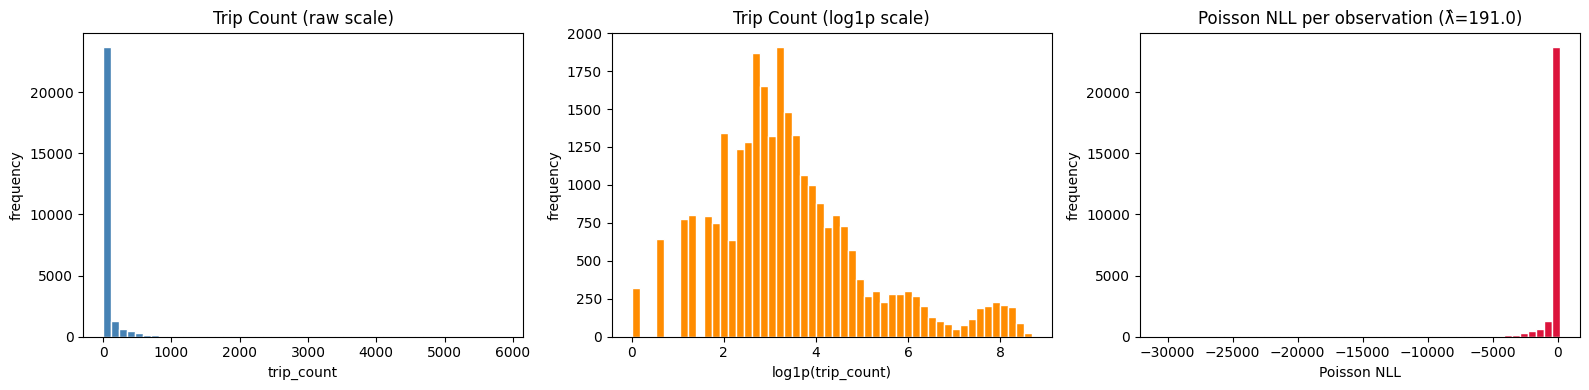

In [44]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (\u03bb\u0302={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()